Objective

The objective of this notebook is to explore transaction patterns, customer behavior, spending trends, and fraud activity within the credit card transaction dataset.

This analysis aims to uncover meaningful business insights that can support decision-making, customer segmentation, fraud detection strategies, and Power BI dashboard development.

Key Focus Areas

• Revenue Analysis

• Customer Spending Behavior

• Category Performance

• Geographic Analysis

• Time-Based Trends

• Fraud Analysis

• Business Insights



In [4]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("/content/fintech_cleaned.csv")

df.shape

(100000, 31)

In [5]:
df.head()

,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,city,...,is_fraud,merch_zipcode,age,age_group,year,month,day,hour,customer_name,revenue_segment
0,2019-01-01 00:00:18,2703186189652095,"fraud_Rippin, Kub and Mann",misc_net,4.97,Jennifer,Banks,F,561 Perry Cove,Moravian Falls,...,0,28705.0,38,36-45,2019,1,1,0,Jennifer Banks,Low
1,2019-01-01 00:00:44,630423337322,"fraud_Heller, Gutmann and Zieme",grocery_pos,107.23,Stephanie,Gill,F,43039 Riley Greens Suite 393,Orient,...,0,NaN,48,46-55,2019,1,1,0,Stephanie Gill,High
2,2019-01-01 00:00:51,38859492057661,fraud_Lind-Buckridge,entertainment,220.11,Edward,Sanchez,M,594 White Dale Suite 530,Malad City,...,0,83236.0,64,56-65,2019,1,1,0,Edward Sanchez,Premium
3,2019-01-01 00:01:16,3534093764340240,"fraud_Kutch, Hermiston and Farrell",gas_transport,45.00,Jeremy,White,M,9443 Cynthia Court Apt. 038,Boulder,...,0,NaN,59,56-65,2019,1,1,0,Jeremy White,Medium
4,2019-01-01 00:03:06,375534208663984,fraud_Keeling-Crist,misc_pos,41.96,Tyler,Garcia,M,408 Bradley Rest,Doe Hill,...,0,22844.0,40,36-45,2019,1,1,0,Tyler Garcia,Medium


In [6]:
monthly_revenue = df.groupby('month')['amt'].sum()

monthly_revenue

,amt
month,
1,3759750.03
2,3431073.19


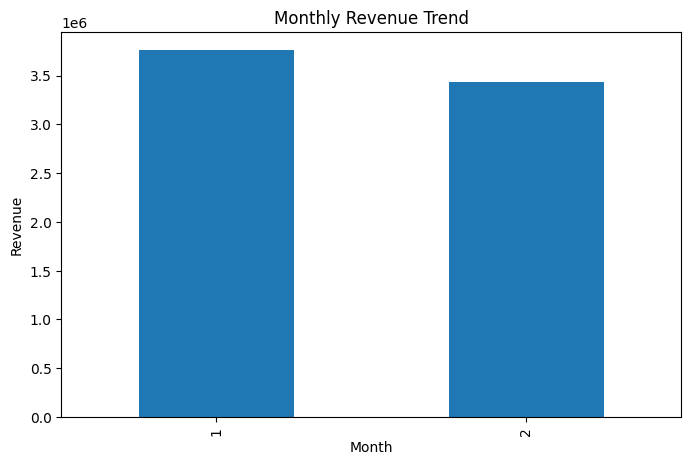

In [7]:
plt.figure(figsize=(8,5))

monthly_revenue.plot(kind='bar')

plt.title('Monthly Revenue Trend')
plt.xlabel('Month')
plt.ylabel('Revenue')

plt.show()

January generated the highest revenue with approximately $3.76 million in transaction value, while February generated approximately $3.43 million.

The observed decline in revenue indicates a possible seasonal variation in customer spending behavior. Further analysis on the complete dataset can provide deeper insights into long-term revenue trends.

In [8]:
hourly_revenue = df.groupby('hour')['amt'].sum()

hourly_revenue

,amt
hour,
0,272069.72
1,283872.54
2,268927.56
3,274240.48
4,245823.80
5,250773.44
6,253418.99
7,245567.98
8,241374.25


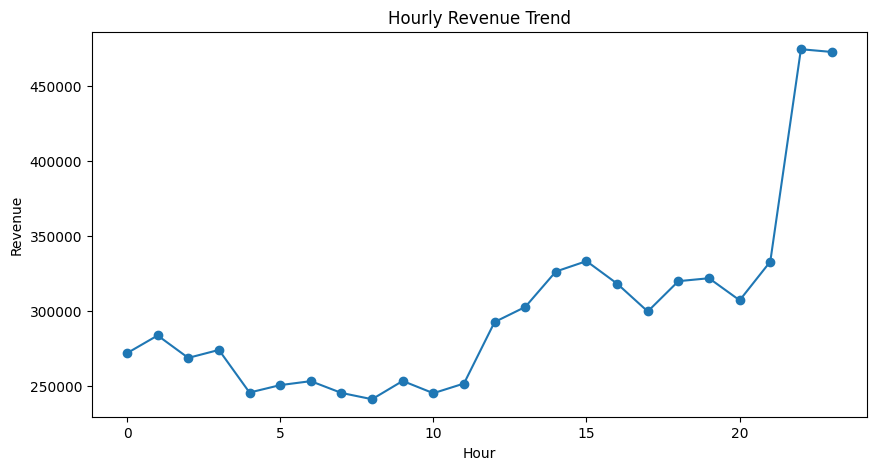

In [9]:
plt.figure(figsize=(10,5))

hourly_revenue.plot(kind='line', marker='o')

plt.title("Hourly Revenue Trend")
plt.xlabel("Hour")
plt.ylabel("Revenue")

plt.show()

Transaction activity increases significantly during the afternoon and evening
hours.

The highest revenue was recorded at 10 PM and 11 PM, indicating that customers prefer making purchases during late evening hours. Morning hours generated comparatively lower revenue.

This pattern can be useful for targeted promotions, customer engagement campaigns, and transaction monitoring strategies.





In [10]:
category_revenue = df.groupby('category')['amt'].sum().sort_values(ascending=False)

category_revenue

,amt
category,
grocery_pos,1140033.24
shopping_net,773527.93
shopping_pos,725766.14
gas_transport,648804.24
home,556526.53
kids_pets,497834.21
entertainment,470949.08
misc_net,428731.66
misc_pos,373078.51


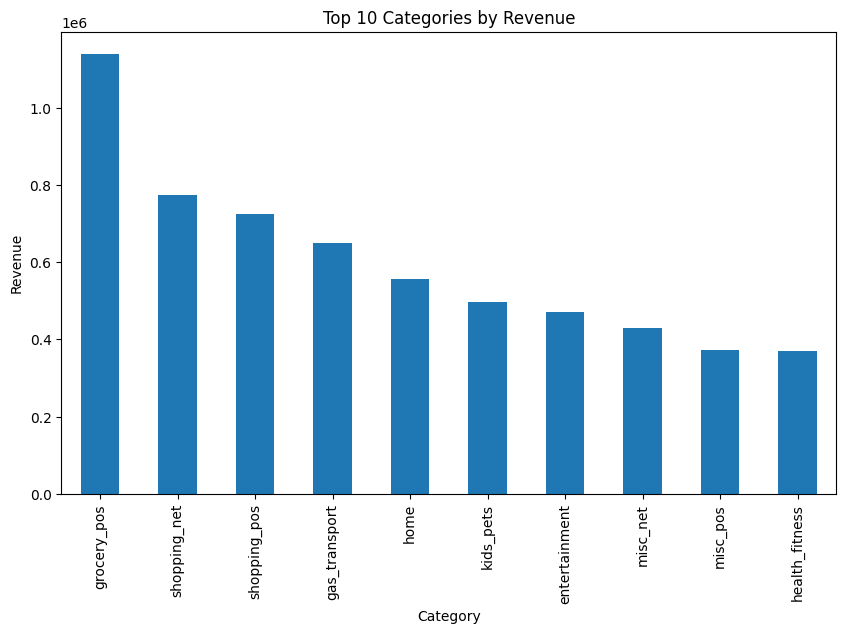

In [11]:
plt.figure(figsize=(10,6))

category_revenue.head(10).plot(kind='bar')

plt.title('Top 10 Categories by Revenue')
plt.xlabel('Category')
plt.ylabel('Revenue')

plt.show()

Grocery POS generated the highest revenue, contributing approximately $1.14 million in transaction value. Shopping-related categories were also major contributors, indicating strong customer engagement in both online and offline retail purchases.


The revenue distribution suggests that essential spending categories such as groceries, shopping, transportation, and home-related purchases drive the majority of transaction volume.


These categories represent potential opportunities for customer loyalty programs, targeted promotions, and strategic partnerships.

In [12]:
fraud_count = df['is_fraud'].value_counts()

fraud_count

,count
is_fraud,
0,99010
1,990


In [13]:
fraud_rate = (df['is_fraud'].sum() / len(df)) * 100

print(f"Fraud Rate: {fraud_rate:.2f}%")

Fraud Rate: 0.99%


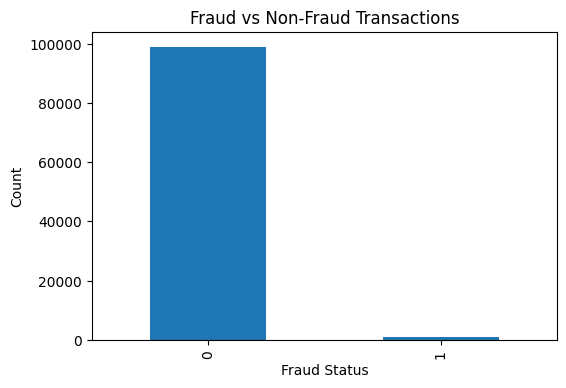

In [14]:
plt.figure(figsize=(6,4))

fraud_count.plot(kind='bar')

plt.title('Fraud vs Non-Fraud Transactions')
plt.xlabel('Fraud Status')
plt.ylabel('Count')

plt.show()

The dataset contains 990 fraudulent transactions out of 100,000 total transactions, resulting in a fraud rate of approximately 0.99%.

Although fraudulent transactions represent a small portion of overall activity, they can significantly impact financial institutions through monetary losses, operational costs, and customer trust issues.

Continuous monitoring and fraud detection mechanisms are essential to minimize financial risk.

In [15]:
fraud_by_category = (
    df[df['is_fraud'] == 1]
    .groupby('category')['is_fraud']
    .count()
    .sort_values(ascending=False)
)

fraud_by_category

,is_fraud
category,
grocery_pos,246
shopping_net,218
misc_net,124
shopping_pos,112
gas_transport,86
kids_pets,37
misc_pos,31
personal_care,28
entertainment,21


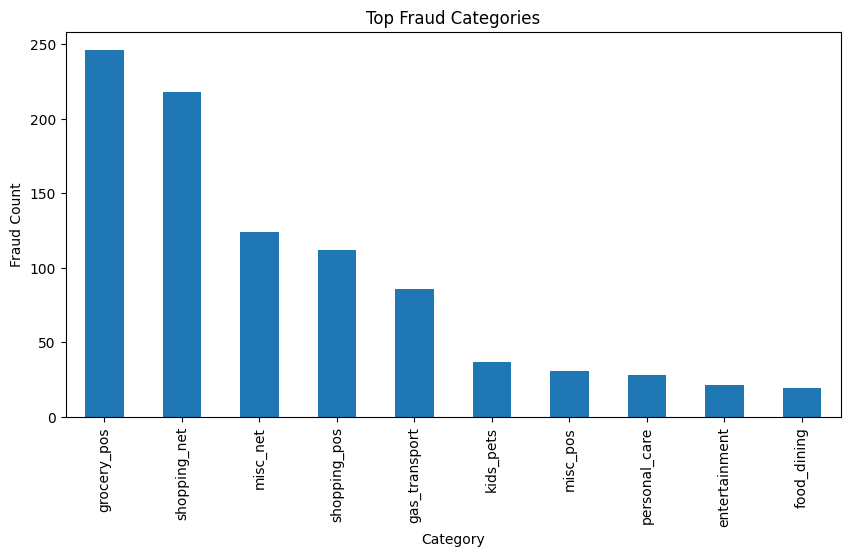

In [16]:
plt.figure(figsize=(10,5))

fraud_by_category.head(10).plot(kind='bar')

plt.title('Top Fraud Categories')
plt.xlabel('Category')
plt.ylabel('Fraud Count')

plt.show()

Fraudulent transactions are concentrated primarily in Grocery POS and Shopping Net categories. These categories account for a significant proportion of all detected fraud cases.

The results indicate that both retail and online shopping transactions represent higher fraud exposure compared to other spending categories.

Financial institutions should prioritize fraud detection efforts within these transaction categories through advanced monitoring, anomaly detection, and customer verification mechanisms.

In [17]:
state_revenue = (
    df.groupby('state')['amt']
    .sum()
    .sort_values(ascending=False)
)

state_revenue.head(10)

,amt
state,
NY,519940.11
TX,515098.53
PA,465608.72
CA,307875.37
OH,283609.21
MI,280495.25
IL,250775.40
FL,249401.84
AL,209832.14


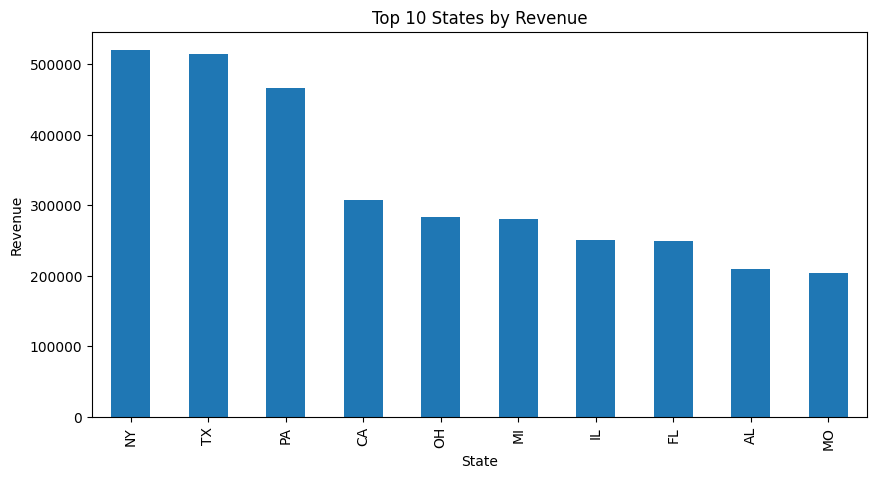

In [18]:
plt.figure(figsize=(10,5))

state_revenue.head(10).plot(kind='bar')

plt.title('Top 10 States by Revenue')
plt.xlabel('State')
plt.ylabel('Revenue')

plt.show()

New York, Texas, and Pennsylvania generated the highest transaction revenue among all states analyzed.

These regions represent the strongest markets within the dataset and contribute a significant share of total transaction value. Strategic investments in customer retention, targeted marketing, and regional partnerships may further strengthen revenue growth in these locations.

In [19]:
job_revenue = (
    df.groupby('job')['amt']
    .sum()
    .sort_values(ascending=False)
)

job_revenue.head(10)

,amt
job,
Film/video editor,61318.97
Exhibition designer,50772.77
Sub,49222.08
"Surveyor, land/geomatics",49195.79
Petroleum engineer,47186.88
Environmental consultant,45292.71
Comptroller,45203.54
Systems developer,44525.00
Agricultural consultant,44132.78


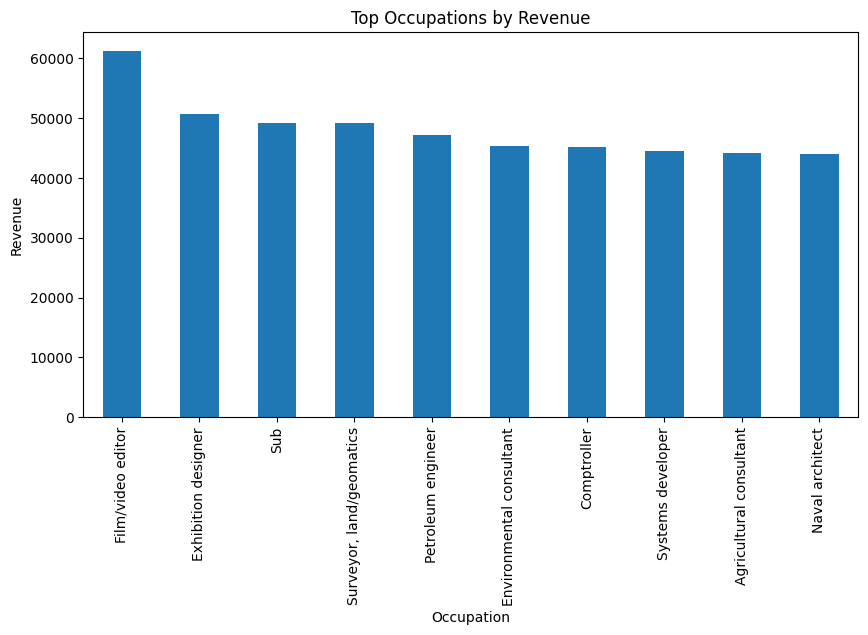

In [20]:
plt.figure(figsize=(10,5))

job_revenue.head(10).plot(kind='bar')

plt.title('Top Occupations by Revenue')
plt.xlabel('Occupation')
plt.ylabel('Revenue')

plt.show()

Certain occupations such as Film/Video Editor, Exhibition Designer, and Petroleum Engineer generated higher transaction revenue compared to other professions.

This indicates the presence of high-value customer segments across specific professional categories. Further analysis using average customer spending and transaction frequency can provide deeper insights into occupation-based purchasing behavior.

In [21]:
segment_revenue = df.groupby('revenue_segment')['amt'].sum()

segment_revenue

,amt
revenue_segment,
High,2822620.45
Low,302928.61
Medium,1741883.75
Premium,2323390.41


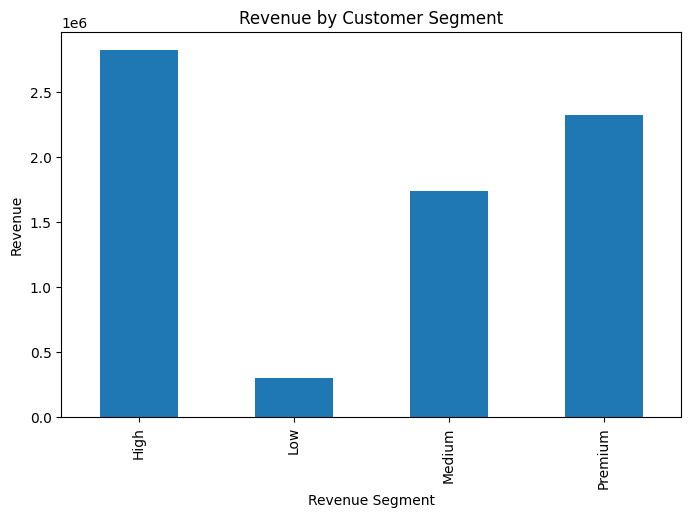

In [22]:
plt.figure(figsize=(8,5))

segment_revenue.plot(kind='bar')

plt.title('Revenue by Customer Segment')
plt.xlabel('Revenue Segment')
plt.ylabel('Revenue')

plt.show()

High-value customers generated the highest overall revenue, contributing approximately $2.82 million.

Although Premium customers spend significantly more per transaction, the larger population of High-value customers results in greater total revenue contribution.

Organizations should focus on retaining Premium customers while also creating strategies to convert Medium-value customers into High-value customers.

In [23]:
top_customers = (
    df.groupby('customer_name')['amt']
    .sum()
    .sort_values(ascending=False)
)

top_customers.head(10)

,amt
customer_name,
Jeffrey Smith,26519.64
Joanna Hudson,25972.20
Jessica Ward,24613.72
Michelle Johnston,24325.95
Erin Chavez,22958.90
Jessica Perez,22933.18
Jodi Rodriguez,22003.41
David Miller,21997.99
Rebecca Erickson,21706.21


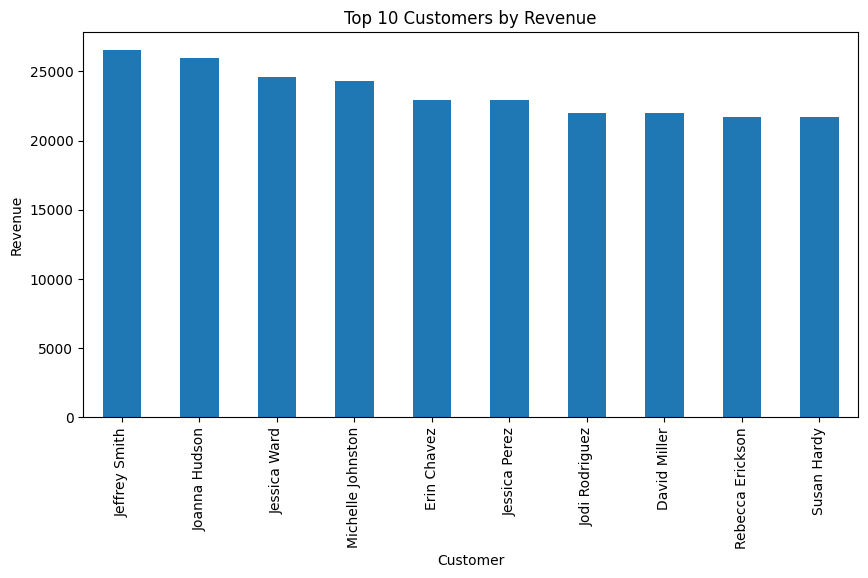

In [24]:
plt.figure(figsize=(10,5))

top_customers.head(10).plot(kind='bar')

plt.title('Top 10 Customers by Revenue')
plt.xlabel('Customer')
plt.ylabel('Revenue')

plt.show()

A small group of customers contributes a disproportionately high share of total revenue. Jeffrey Smith, Joanna Hudson, and Jessica Ward are among the highest revenue-generating customers in the analyzed sample.

These customers represent high-value segments and may benefit from personalized engagement strategies, loyalty programs, and premium service offerings to improve retention and lifetime value.

# Executive Summary

1. January generated the highest revenue among the available months.
2. Customer spending peaks during late evening hours, especially between 10 PM and 11 PM.
3. Grocery POS is the highest revenue-generating category.
4. Fraud rate is approximately 0.99% of all transactions.
5. Grocery POS and Shopping Net are the most fraud-prone categories.
6. New York and Texas are the strongest revenue-generating states.
7. High-value customers contribute the largest share of revenue.
8. Premium customers represent a smaller but strategically important customer segment.
9. A small group of customers contributes significantly to overall revenue.

These findings support customer segmentation, fraud monitoring, targeted marketing, and strategic business decision-making.